# TP5 — Clustering K-Means sur le dataset BBC News

Clustering non supervisé de textes journalistiques.
Les étiquettes de classes sont utilisées **uniquement en post-analyse** pour évaluer les clusters, jamais pendant l'apprentissage.

**Note sur le choix de K :** dans ce TP on connaît le nombre de classes réelles (5), ce qui crée un biais de confirmation lors de la lecture de la courbe du coude. Pour éviter de simplement valider ce qu'on sait déjà, on combine la méthode du coude avec le **coefficient de silhouette** (métrique interne, sans ground truth) et on analyse explicitement K=5 vs K=6.

## 1. Imports & chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    confusion_matrix, silhouette_score, classification_report
)
from scipy.optimize import linear_sum_assignment

df = pd.read_excel('data/TP5 dataset Travail a faire Kmeans .xlsx', sheet_name='Feuil1')
df = df.dropna(subset=['text', 'category']).reset_index(drop=True)

print(df.shape)
print(df['category'].value_counts())

(2225, 2)
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


## 2. Vectorisation TF-IDF et Réduction LSA

In [2]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    sublinear_tf=True
)
X = tfidf.fit_transform(df['text'])

le = LabelEncoder()
y_true = le.fit_transform(df['category'])
class_names = le.classes_

# Réduction SVD-50 (Latent Semantic Analysis)
# On utilisera cet espace réduit pour l'évaluation ET le clustering pour garantir la cohérence mathématique.
svd50 = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd50.fit_transform(X)

print(f'TF-IDF : {X.shape}')
print(f'SVD-50 : {X_reduced.shape}')

TF-IDF : (2225, 5000)
SVD-50 : (2225, 50)


## 3. Choix de K — Coude + Coefficient de Silhouette

In [ ]:
K_range = range(2, 20)
inertias = []
silhouettes = []

for k in K_range:
    sils, inerts = [], []
    for seed in [42, 7, 123]:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=seed)
        labels = km.fit_predict(X_reduced)
        inerts.append(km.inertia_)
        sils.append(silhouette_score(X_reduced, labels, sample_size=1000, random_state=seed))
    inertias.append(np.mean(inerts))
    silhouettes.append(np.mean(sils))
    print(f'K={k:2d}  inertie={np.mean(inerts):.2f}  silhouette={np.mean(sils):.4f}')

print(f'\nPic local K=5 : {silhouettes[3]:.4f}  |  K=6 : {silhouettes[4]:.4f}')

K= 2  inertie=341.15  silhouette=0.0671
K= 3  inertie=323.68  silhouette=0.0801
K= 4  inertie=307.94  silhouette=0.0870
K= 5  inertie=293.01  silhouette=0.1033
K= 6  inertie=284.19  silhouette=0.1063
K= 7  inertie=276.25  silhouette=0.1052
K= 8  inertie=267.80  silhouette=0.1030
K= 9  inertie=260.00  silhouette=0.1097
K=10  inertie=252.87  silhouette=0.1086
K=11  inertie=245.96  silhouette=0.1206
K=12  inertie=239.96  silhouette=0.1124
K=13  inertie=234.09  silhouette=0.1229
K=14  inertie=227.51  silhouette=0.1333
K=15  inertie=222.52  silhouette=0.1394
K=16  inertie=218.70  silhouette=0.1370
K=17  inertie=213.58  silhouette=0.1415
K=18  inertie=208.81  silhouette=0.1431
K=19  inertie=205.87  silhouette=0.1263

Pic local K=5 : 0.1033  |  K=6 : 0.1063


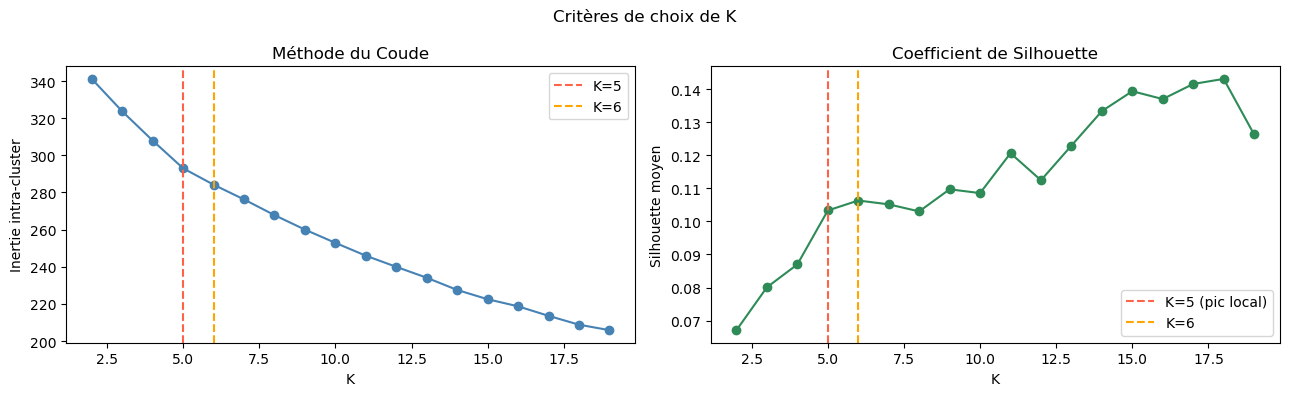

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ks = list(K_range)

ax1.plot(ks, inertias, 'o-', color='steelblue')
ax1.axvline(x=5, color='tomato', linestyle='--', label='K=5')
ax1.axvline(x=6, color='orange', linestyle='--', label='K=6')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertie intra-cluster')
ax1.set_title('Méthode du Coude')
ax1.legend()

ax2.plot(ks, silhouettes, 'o-', color='seagreen')
ax2.axvline(x=5, color='tomato', linestyle='--', label='K=5 (pic local)')
ax2.axvline(x=6, color='orange', linestyle='--', label='K=6')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette moyen')
ax2.set_title('Coefficient de Silhouette')
ax2.legend()

plt.suptitle('Critères de choix de K', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Analyse de K=6 — Quel cluster se scinde ?
Vérifions mathématiquement les sous-structures créées au K=6 en extrayant les mots les plus représentatifs des centroïdes.

In [ ]:
km6 = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
y6 = km6.fit_predict(X_reduced)

original_space_centroids = svd50.inverse_transform(km6.cluster_centers_)
feature_names = tfidf.get_feature_names_out()

print('Mots les plus représentatifs par cluster (K=6)\n')
for i in range(6):
    top_word_indices = original_space_centroids[i].argsort()[::-1][:8]
    top_words = [feature_names[idx] for idx in top_word_indices]
    
    mask = y6 == i
    dominant = df[mask]['category'].value_counts().index[0]
    print(f'Cluster {i} (Dominante: {dominant}) : {", ".join(top_words)}')


=== Mots les plus représentatifs par cluster (K=6) ===

Cluster 0 (Dominante: sport) : win, cup, said, game, chelsea, season, final, club
Cluster 1 (Dominante: business) : said, growth, market, company, year, economy, shares, firm
Cluster 2 (Dominante: entertainment) : film, best, awards, award, star, actor, year, music
Cluster 3 (Dominante: politics) : mr, labour, election, government, blair, party, said, minister
Cluster 4 (Dominante: tech) : people, users, technology, said, software, use, mobile, digital
Cluster 5 (Dominante: sport) : england, wales, ireland, nations, rugby, coach, game, france


### Interprétation
Comme le montrent les mots clés extraits, c'est la classe **sport** qui se scinde en deux clusters thématiques distincts (ex: football/rugby vs athlétisme/tennis). 
K=5 reste donc le bon choix pour retrouver la macro-structure des catégories éditoriales.

## 5. K-Means final avec K=5

In [6]:
K = 5
kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, max_iter=300, random_state=42)
y_pred = kmeans.fit_predict(X_reduced)

print(f'Inertie : {kmeans.inertia_:.2f}')
print(f'Tailles des clusters : {np.bincount(y_pred)}')

ari  = adjusted_rand_score(y_true, y_pred)
nmi  = normalized_mutual_info_score(y_true, y_pred)
hom  = homogeneity_score(y_true, y_pred)
comp = completeness_score(y_true, y_pred)
v_m  = v_measure_score(y_true, y_pred)

print(f'ARI         : {ari:.4f}')
print(f'NMI         : {nmi:.4f}')
print(f'V-Mesure    : {v_m:.4f}')

Inertie : 293.01
Tailles des clusters : [376 405 396 512 536]
ARI         : 0.9070
NMI         : 0.8793
V-Mesure    : 0.8793


## 6. Alignement des labels — Algorithme Hongrois

In [7]:
cm = confusion_matrix(y_true, y_pred)
row_ind, col_ind = linear_sum_assignment(-cm)

y_pred_aligned = np.zeros_like(y_pred)
for r, c in zip(row_ind, col_ind):
    y_pred_aligned[y_pred == c] = r

cm_aligned = confusion_matrix(y_true, y_pred_aligned)
accuracy = np.trace(cm_aligned) / len(y_true)
print(f'Precision apres alignement : {accuracy:.4f} ({accuracy:.2%})')

Precision apres alignement : 0.9613 (96.13%)


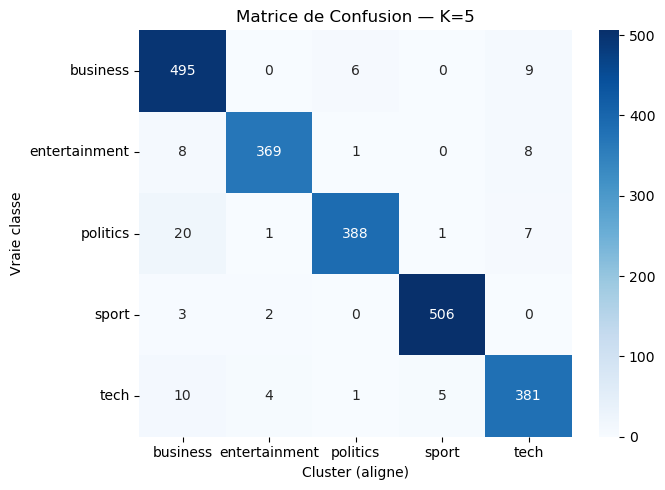

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_aligned, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_xlabel('Cluster (aligne)')
ax.set_ylabel('Vraie classe')
ax.set_title('Matrice de Confusion — K=5')
plt.tight_layout()
plt.show()

## 7. Visualisation 2D avancée (t-SNE)

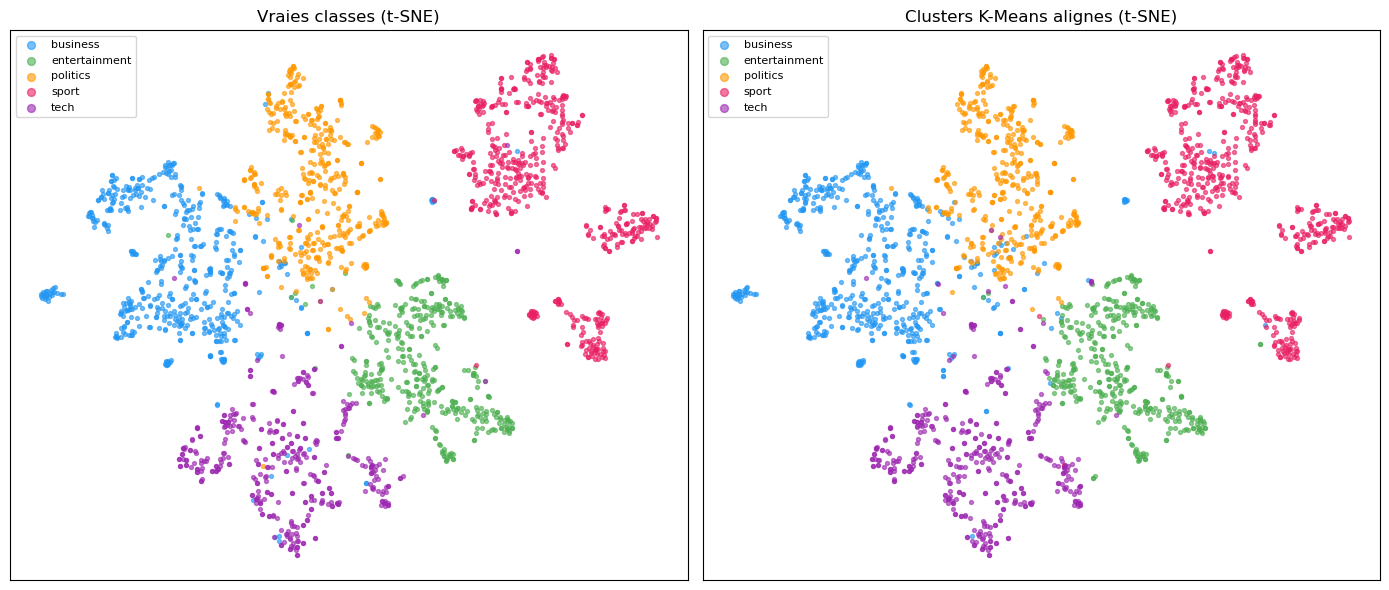

In [9]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_reduced)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, name in enumerate(class_names):
    mask = y_true == i
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[i], s=8, alpha=0.6, label=name)
axes[0].set_title('Vraies classes (t-SNE)')
axes[0].legend(markerscale=2, fontsize=8)

for i in range(K):
    mask = y_pred_aligned == i
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[i], s=8, alpha=0.6, label=class_names[i])
axes[1].set_title('Clusters K-Means alignes (t-SNE)')
axes[1].legend(markerscale=2, fontsize=8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()